In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from collections import Counter
from pprint import pprint

In [32]:
INPUT_FILES = ["qa_1_200_Atlas-Chat-9B_Atlas-Chat-2B.json", "qa_201_1525_gemini3Flash_gemini3Flash.json", "qa_1526_1747_gemini3Flash_Atlas-Chat-2B.json", "qa_3051_4575_gemini3Flash_gemini3Flash.json", "qa_4576_6100_gemini3Flash_gemini3Flash.json"]
count = 0
questions = {}
for file in INPUT_FILES:
    with open("../datasets/processed/question_answer/" + file, "r", encoding="utf-8") as f:
        data = json.load(f)
        print(f"file: {file} count: {len(data)}")
        for task in data:
            question = task["data"]["question"].split()[0]
            questions[question] = questions.get(question, 0) + 1
        count += len(data)
from pprint import pprint
pprint(questions)
print(f"Total: {count}")

file: qa_1_200_Atlas-Chat-9B_Atlas-Chat-2B.json count: 200
file: qa_201_1525_gemini3Flash_gemini3Flash.json count: 1250
file: qa_1526_1747_gemini3Flash_Atlas-Chat-2B.json count: 200
file: qa_3051_4575_gemini3Flash_gemini3Flash.json count: 770
file: qa_4576_6100_gemini3Flash_gemini3Flash.json count: 1010
{'/': 1,
 'امتا': 202,
 'شحال': 530,
 'شكون': 411,
 'شنو': 518,
 'فوقاش': 467,
 'فين': 599,
 'معامن': 248,
 'وقتاش': 454}
Total: 3430


In [7]:
def extract_annotation(annotation: dict) -> dict[str, str]:
    result = annotation["result"]
    data = {
        "question": "",
        "answer": "",
        "question_label": "",
        "answer_label": "",
    }

    for r in result:
        name: str = r["from_name"]
        if name == "question_corrected":
            data["question"] = r["value"]["text"][0]
        elif name == "answer_corrected":
            data["answer"] = r["value"]["text"][0]
        elif name == "question_error":
            data["question_label"] = r["value"]["choices"][0]
        elif name == "answer_error":
            data["answer_label"] = r["value"]["choices"][0]

    return data

def load_and_extract(
    input_file: str,
    base_path: str = "../datasets/processed/question_answer_validated_label_studio/",
) -> list[dict[str, str]]:

    file_path = base_path + input_file
    with open(file_path, "r", encoding="utf-8") as f:
        tasks: list[dict] = json.load(f)

    extracted: list[dict[str, str]] = []
    for task in tasks:
        annotations: list[dict] = task.get("annotations", [])
        if not annotations:
            continue
        annotation = annotations[0]
        data = extract_annotation(annotation)
        extracted.append({
            "context":            task["data"]["context"],
            "question_corrected": data["question"],
            "answer_corrected":   data["answer"],
            "question_label":     data["question_label"],
            "answer_label":       data["answer_label"],
        })
    return extracted

In [31]:
base_path: str = "../datasets/processed/question_answer/"    
file_path = base_path + "qa_3051_4575_gemini3Flash_gemini3Flash.json"

with open(file_path, "r", encoding="utf-8") as f:
    tasks: list[dict] = json.load(f)

for i, task in enumerate(tasks):
    if i > 450:
        if "وقتاش" in task["data"]["question"]:
            if i % 2 == 0:
                task["data"]["question"] = task["data"]["question"].replace("وقتاش", "فوقاش")
            else:
                task["data"]["question"] = task["data"]["question"].replace("وقتاش", "امتا")

with open(file_path, "w", encoding="utf-8") as f:
    json.dump(tasks, f, ensure_ascii=False ,indent=2)
print(len(tasks))

770


In [19]:
import pandas as pd

df = pd.read_csv("../datasets/processed/goud_preprocessed_V2.csv")

for i in range(df.shape[0]):
    if "العمل من أجل تحقيق الإنصاف المجالي والنهوض بالمناطق الهشة والف" in df["context"].iloc[i]:
        print(i)

        
        

4804


In [20]:
base_path: str = "../datasets/processed/question_answer_validated_label_studio/"    
file_path = base_path + "qa_4576_4804_gemini3Flash_gemini3Flash.json"
out_path = base_path + "qa_4576_4804_gemini3Flash_gemini3Flash_V2.json"

# with open(file_path, "r", encoding="utf-8") as f:
#     tasks: list[dict] = json.load(f)

extracted = load_and_extract("qa_4576_4804_gemini3Flash_gemini3Flash.json")
# with open(out_path, "r", encoding="utf-8") as f:
#     tasks: list[dict] = json.load(f)

with open("../datasets/processed/question_answer/qa_4576_6100_gemini3Flash_gemini3Flash.json", "r", encoding="utf-8") as f:
    old: list[dict] = json.load(f)

for task in extracted:
    context = task["context"]
    for t in old:
        old_context = t["data"]["context"]
        if old_context == context:
            task["question"] = t["data"]["question"]
            task["answer"] = t["data"]["answer"]
            break

with open(out_path, "w", encoding="utf-8") as f:
    json.dump(extracted, f, ensure_ascii=False ,indent=2)

In [6]:
extracted = load_and_extract("qa_1526_1747_gemini3Flash_Atlas-Chat-2B.json")
for el in extracted:
    print(f"question: {el["question_corrected"]}")
    print(f"label: {el["question_label"]}")

question: شكون استقبل وفد برلمان مجموعة دول (CEMAC) فمدينة العيون؟
label: Correct
question: فوقاش غادي يتم تقديم هاد الستة ديال الأشخاص على الوكيل العام للملك بمدينة فاس؟
label: Correct
question: شحال من صفحة كاينين ف التقرير اللي قدمو أنطونيو گوتيريش بخصوص الحالة ف الصحراء؟
label: Correct
question: فين وقع هاد الانهيار ديال السور اللي تسبب فوفاة العساس؟
label: Correct
question: شكون غادي يترأس مجلس الحكومة اللي غينعقد بعد غد الخميس؟
label: Correct
question: شكون هو الفريق المغربي اللي مرشح لجائزة أحسن فريق إفريقي ديال العيالات لعام 2024؟
label: Correct
question: شكون هو رئيس المجلس الاقتصادي والاجتماعي والبيئي؟
label: Correct
question: شنو هما الناس اللي كيجيو بزاف ديال الناس فالعالم الخوف منهم؟
label: Correct
question: شنو هي المادة اللي بانت فيها أزمة جديدة من بعد الأزمة ديال البصل فماكدونالدز؟
label: Correct
question: فين قررت غرفة الجنح التلبسية تأخير محاكمة صاحب قناة "مول القرطاسة"؟
label: Correct
question: شحال من سد كبير كاين فالمغرب على حساب التصريح ديال نزار بركة؟
label: Corr

In [26]:
LABELS_ORDER = ["Correct", "Grammar Error", "Spelling Error", "Ambiguous", "Incomplete"]

LABEL_COLORS = {
    "Correct":       "#2ecc71",
    "Grammar Error": "#e74c3c",
    "Spelling Error":"#e67e22",
    "Ambiguous":     "#9b59b6",
    "Incomplete":    "#3498db",
}

INPUT_FILES = [
    "qa_1_200_Atlas-Chat-9B_Atlas-Chat-2B.json",
    "qa_1526_1747_gemini3Flash_Atlas-Chat-2B.json",
]

dfs = []

for file in INPUT_FILES:
    parts                 = file.split(".")[0].split("_")
    question_generated_by = parts[-2]
    answer_generated_by   = parts[-1]

    df_tmp = pd.DataFrame(load_and_extract(file))
    df_tmp["question_model"] = question_generated_by
    df_tmp["answer_model"]   = answer_generated_by
    dfs.append(df_tmp)

df = pd.concat(dfs, ignore_index=True)
df["question_label"] = df["question_label"].str.strip().str.title()
df["is_correct"]     = df["question_label"] == "Correct"
df["question_len"]   = df["question_corrected"].str.len()
df["context_len"]   = df["context"].str.len()

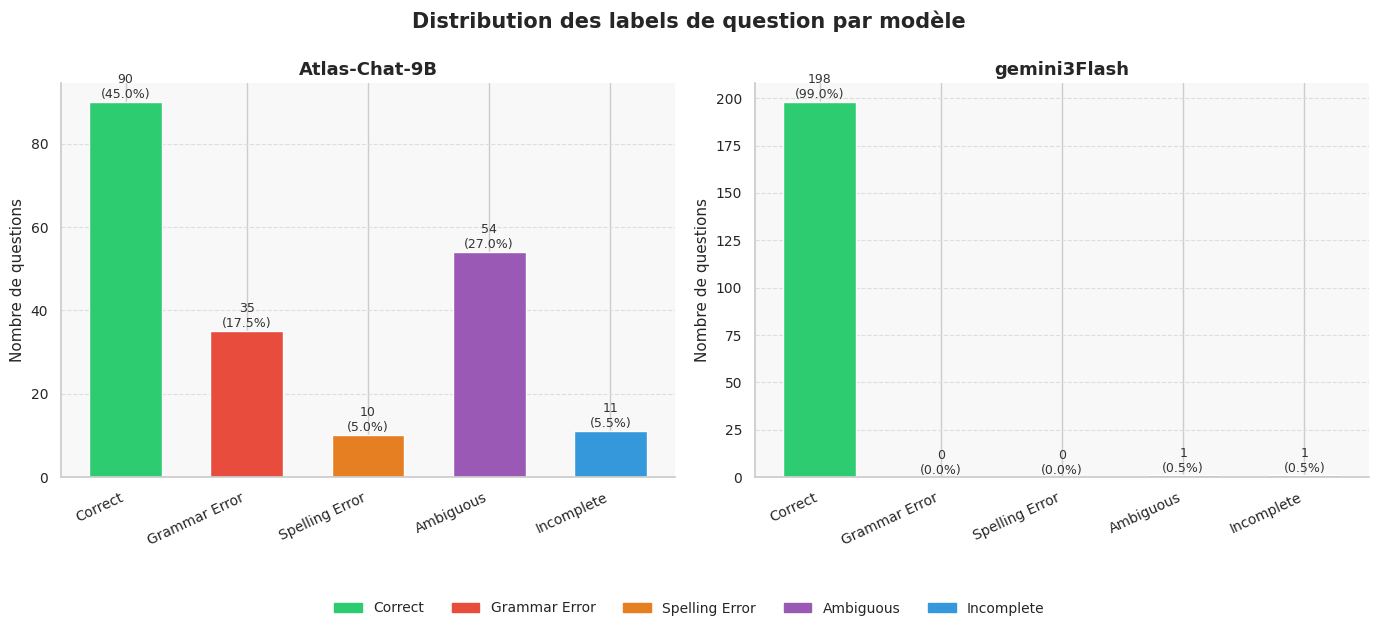

In [30]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(7 * len(MODELS), 6), sharey=False)
fig.suptitle("Distribution des labels de question par modèle", fontweight="bold", fontsize=15)

for ax, model in zip(axes, MODELS):
    sub    = df[df["question_model"] == model]
    counts = sub["question_label"].value_counts().reindex(LABELS_ORDER, fill_value=0)
    colors = [LABEL_COLORS[l] for l in counts.index]

    bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", width=0.6)

    # style matplotlib pur
    ax.set_facecolor("#f8f8f8")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.yaxis.grid(True, color="#dddddd", linestyle="--", linewidth=0.8)
    ax.set_axisbelow(True)

    ax.set_title(f"{model}", fontsize=13, fontweight="bold")
    ax.set_ylabel("Nombre de questions", fontsize=11)
    ax.set_xlabel("")
    ax.set_xticks(range(len(counts.index)))
    ax.set_xticklabels(counts.index, rotation=25, ha="right", fontsize=10)
    ax.tick_params(axis="y", labelsize=10)

    for bar, val in zip(bars, counts.values):
        pct = val / len(sub) * 100
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f"{val}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=9, color="#333333",
        )

# légende globale
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=LABEL_COLORS[l], label=l)
    for l in LABELS_ORDER
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(LABELS_ORDER),
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("01_label_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

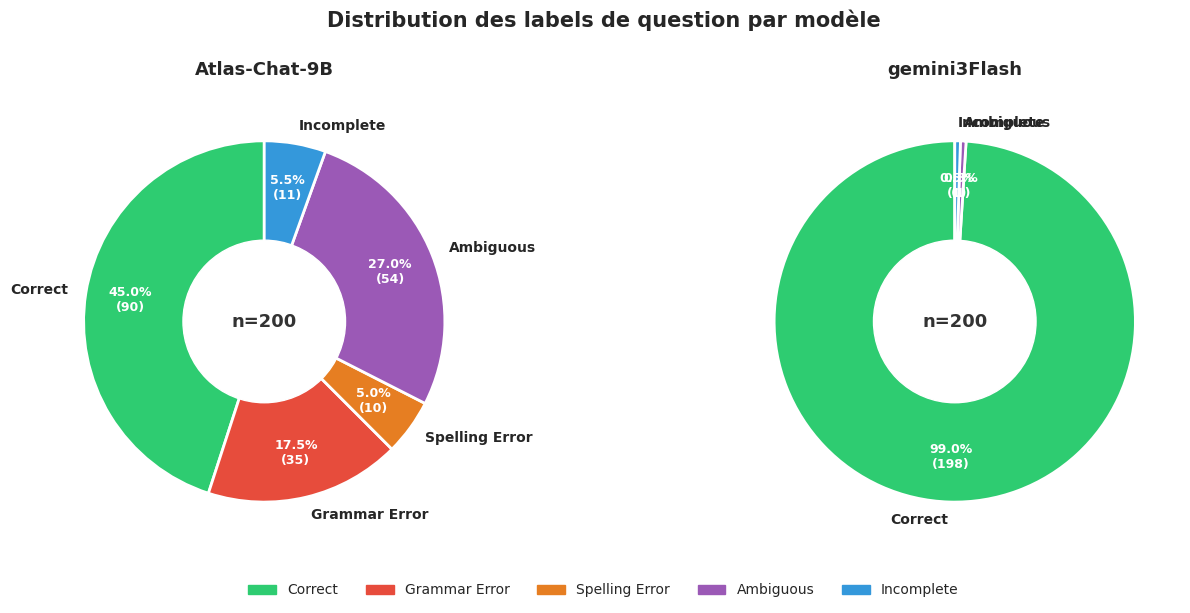

In [31]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(7 * len(MODELS), 6))
fig.suptitle("Distribution des labels de question par modèle", fontweight="bold", fontsize=15)

for ax, model in zip(axes, MODELS):
    sub    = df[df["question_model"] == model]
    counts = sub["question_label"].value_counts().reindex(LABELS_ORDER, fill_value=0)
    counts = counts[counts > 0]  # exclure labels absents

    colors = [LABEL_COLORS[l] for l in counts.index]

    wedges, texts, autotexts = ax.pie(
        counts.values,
        labels=counts.index,
        colors=colors,
        autopct=lambda p: f"{p:.1f}%\n({int(round(p * len(sub) / 100))})",
        startangle=90,
        pctdistance=0.75,
        wedgeprops=dict(edgecolor="white", linewidth=2),
    )

    # style des textes
    for text in texts:
        text.set_fontsize(10)
        text.set_fontweight("bold")
    for autotext in autotexts:
        autotext.set_fontsize(9)
        autotext.set_color("white")
        autotext.set_fontweight("bold")

    # cercle central → donut
    centre_circle = plt.Circle((0, 0), 0.45, fc="white")
    ax.add_patch(centre_circle)

    # total au centre
    ax.text(
        0, 0, f"n={len(sub)}",
        ha="center", va="center",
        fontsize=13, fontweight="bold", color="#333333"
    )

    ax.set_title(f"{model}", fontsize=13, fontweight="bold", pad=15)

# légende globale
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=LABEL_COLORS[l], label=l)
    for l in LABELS_ORDER
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(LABELS_ORDER),
    fontsize=10,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
)

sns.despine()
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("01_label_distribution_pie.png", dpi=150, bbox_inches="tight")
plt.show()

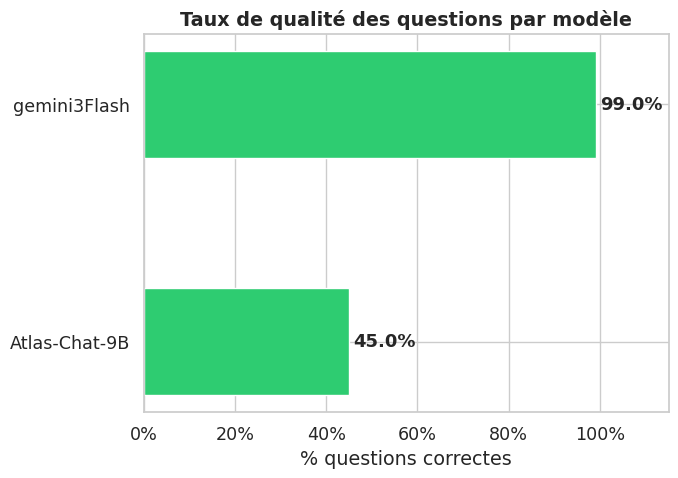

In [32]:

quality = (
    df.groupby("question_model")["is_correct"]
    .mean().mul(100)
    .reset_index(name="pct_correct")
)

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.barh(
    quality["question_model"],
    quality["pct_correct"],
    color=[LABEL_COLORS["Correct"]] * len(quality),
    edgecolor="white", height=0.45,
)
ax.set_xlim(0, 115)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel("% questions correctes")
ax.set_title("Taux de qualité des questions par modèle", fontweight="bold")

for bar, val in zip(bars, quality["pct_correct"]):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("03_quality_rate.png", dpi=150)
plt.show()

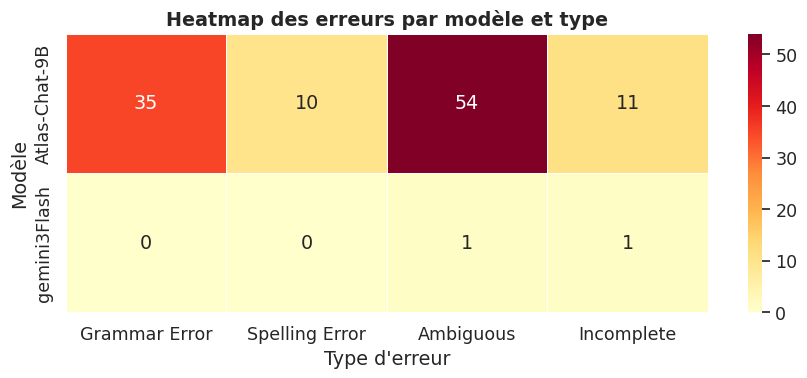

In [33]:

heat_data = (
    df[df["question_label"] != "Correct"]
    .groupby(["question_model", "question_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[l for l in LABELS_ORDER if l != "Correct"], fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    heat_data,
    annot=True, fmt="d",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("Heatmap des erreurs par modèle et type", fontweight="bold")
ax.set_ylabel("Modèle")
ax.set_xlabel("Type d'erreur")

plt.tight_layout()
plt.savefig("05_error_heatmap.png", dpi=150)
plt.show()

/tmp/ipykernel_1092687/377458573.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1092687/377458573.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(present_labels, rotation=25, ha="right")
/tmp/ipykernel_1092687/377458573.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_1092687/377458573.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(present_labels, rotation=25, ha="right")


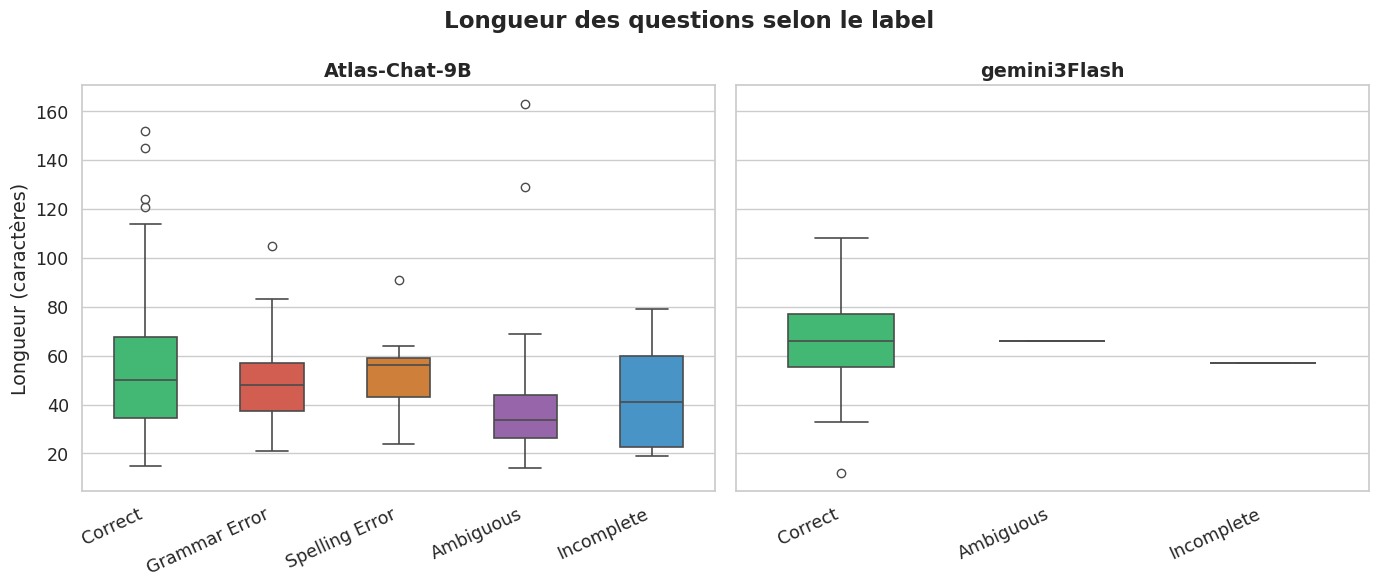

In [34]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(7 * len(MODELS), 6), sharey=True)
fig.suptitle("Longueur des questions selon le label", fontweight="bold")

for ax, model in zip(axes, MODELS):
    sub = df[df["question_model"] == model]
    present_labels = [l for l in LABELS_ORDER if l in sub["question_label"].values]
    palette = {l: LABEL_COLORS[l] for l in present_labels}

    sns.boxplot(
        data=sub,
        x="question_label",
        y="question_len",
        order=present_labels,
        palette=palette,
        width=0.5,
        linewidth=1.2,
        ax=ax,
    )
    ax.set_title(f"{model}", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Longueur (caractères)")
    ax.set_xticklabels(present_labels, rotation=25, ha="right")

plt.tight_layout()
plt.savefig("04_length_boxplot.png", dpi=150)
plt.show()

In [20]:
INPUT_FILES = ["qa_1_200_Atlas-Chat-9B_Atlas-Chat-2B.json", "qa_1526_1747_gemini3Flash_Atlas-Chat-2B.json"]

for file in INPUT_FILES:
    question_generated_by = file.split(".")[0].split("_")[-2]
    answer_generated_by = file.split(".")[0].split("_")[-1]
    results = load_and_extract(file)